In [5]:
# Load & Prepare Data
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned_dataset/cleaned_ticket_prices.csv")

df.head()

,month,conflict_phase,airline,iata_code,country,region,airline_type,route_class,avg_route_km,base_fare_usd,...,yoy_surcharge_change_pct,year,month_num,quarter,is_extreme_fare,fuel_surcharge_ratio,taxes_ratio,base_ratio,crude_jet_ratio,fare_per_km
0,2019-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1179.91,...,0.0,2019,1,2019Q1,False,0.0731,0.1171,0.8098,1.1838,0.1714
1,2019-02,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1176.08,...,0.0,2019,2,2019Q1,False,0.0468,0.0933,0.8599,1.2087,0.1609
2,2019-03,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1133.88,...,0.0,2019,3,2019Q1,False,0.0857,0.0876,0.8267,1.1672,0.1614
3,2019-04,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1237.95,...,0.0,2019,4,2019Q2,False,0.0402,0.1155,0.8442,1.1320,0.1725
4,2019-05,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1270.08,...,0.0,2019,5,2019Q2,False,0.0570,0.1119,0.8311,1.1913,0.1798


In [6]:
cols = [
    'jet_fuel_usd_barrel',
    'brent_crude_usd',
    'total_fare_usd',
    'fuel_cost_pct_opex',
    'yoy_price_change_pct',
    'load_factor_pct'
]

df_selected = df[cols]
df_selected.describe()

,jet_fuel_usd_barrel,brent_crude_usd,total_fare_usd,fuel_cost_pct_opex,yoy_price_change_pct,load_factor_pct
count,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000
mean,93.624138,80.184368,1135.346773,0.280993,31.461953,70.321477
std,28.371276,24.359421,1468.411496,0.096425,99.103267,16.610219
min,23.690000,20.550000,13.890000,0.052000,-80.330000,31.000000
25%,76.870000,66.500000,146.460000,0.223000,-17.945000,64.900000
50%,94.920000,82.610000,470.560000,0.277000,0.000000,73.800000
75%,109.200000,91.480000,1565.400000,0.335000,21.685000,82.800000
max,193.200000,169.080000,12126.260000,0.733000,518.100000,92.000000


In [7]:
df_selected.describe()

,jet_fuel_usd_barrel,brent_crude_usd,total_fare_usd,fuel_cost_pct_opex,yoy_price_change_pct,load_factor_pct
count,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000
mean,93.624138,80.184368,1135.346773,0.280993,31.461953,70.321477
std,28.371276,24.359421,1468.411496,0.096425,99.103267,16.610219
min,23.690000,20.550000,13.890000,0.052000,-80.330000,31.000000
25%,76.870000,66.500000,146.460000,0.223000,-17.945000,64.900000
50%,94.920000,82.610000,470.560000,0.277000,0.000000,73.800000
75%,109.200000,91.480000,1565.400000,0.335000,21.685000,82.800000
max,193.200000,169.080000,12126.260000,0.733000,518.100000,92.000000


The dataset shows high variation in ticket prices (mean ≈ 1135, max ≈ 12126), indicating presence of extreme values. 
Fuel prices also vary significantly, which makes it suitable for impact analysis. 
Load factor is relatively stable compared to other variables.

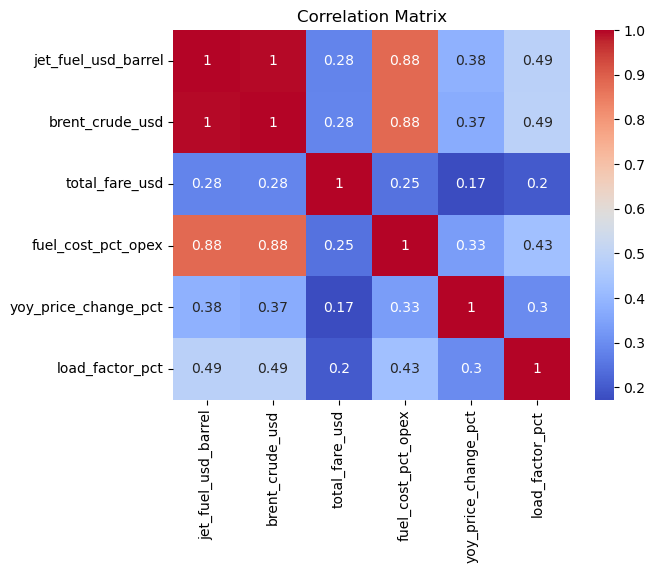

In [8]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_selected.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Jet fuel price has a strong positive correlation with fuel cost percentage (~0.88), showing fuel directly impacts airline costs. 
However, its correlation with ticket price is weak (~0.28), meaning airlines do not fully pass increased fuel costs to customers. 
Brent crude and jet fuel prices are almost perfectly correlated (~1), indicating they move together.

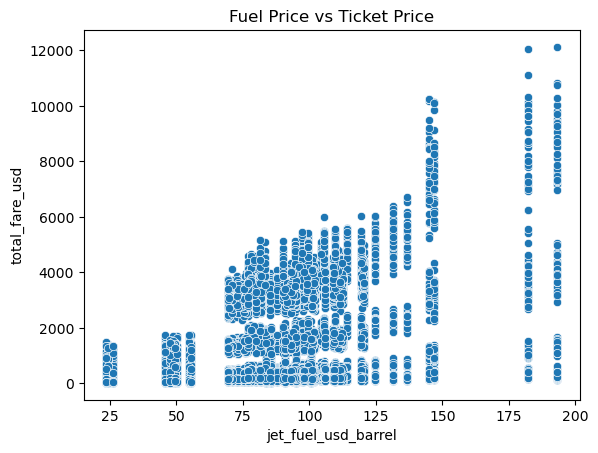

In [9]:
sns.scatterplot(x='jet_fuel_usd_barrel', y='total_fare_usd', data=df)
plt.title("Fuel Price vs Ticket Price")
plt.show()

The scatter plot shows a slight upward trend but with high spread. 
This indicates a weak relationship between fuel price and ticket price, with many other factors influencing pricing.

In [10]:
import statsmodels.api as sm

X = df['jet_fuel_usd_barrel']
y = df['total_fare_usd']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         total_fare_usd   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     1231.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          9.96e-259
Time:                        15:40:59   Log-Likelihood:            -1.2445e+05
No. Observations:               14355   AIC:                         2.489e+05
Df Residuals:                   14353   BIC:                         2.489e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -226.3402    

The regression shows a positive relationship between fuel price and ticket price. 
For every 1 unit increase in fuel price, ticket price increases by ~14.5 units. 
However, R² ≈ 0.08 indicates the model explains very little variation, so fuel price alone is not a strong predictor.

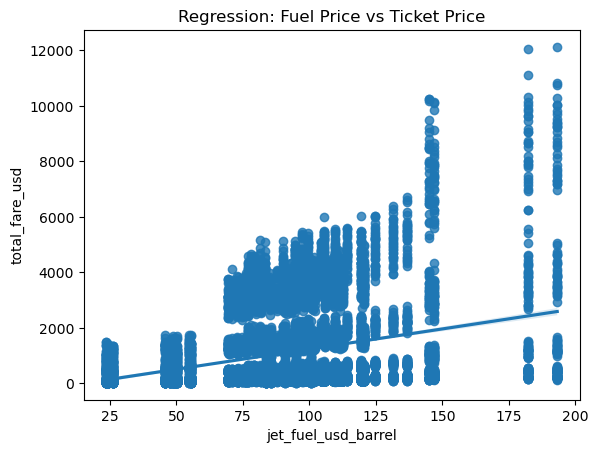

In [11]:
sns.regplot(x='jet_fuel_usd_barrel', y='total_fare_usd', data=df)
plt.title("Regression: Fuel Price vs Ticket Price")
plt.show()

The regression line confirms a positive trend but with high dispersion of points. 
This supports that the relationship exists but is weak and inconsistent.

In [12]:
X = df[['jet_fuel_usd_barrel', 'load_factor_pct']]
y = df['total_fare_usd']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         total_fare_usd   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     659.7
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          8.33e-275
Time:                        15:41:02   Log-Likelihood:            -1.2441e+05
No. Observations:               14355   AIC:                         2.488e+05
Df Residuals:                   14352   BIC:                         2.489e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -545.4133    

Adding load factor slightly improves the model (R² ≈ 0.084). 
Both fuel price and load factor positively impact ticket price. 
However, overall explanatory power remains low, indicating other variables also influence pricing.

In [13]:
p_value = model.pvalues['jet_fuel_usd_barrel']

print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Fuel price significantly affects ticket price")
else:
    print("Fail to reject H0: No significant effect")

P-value: 9.956125346767485e-259
Reject H0: Fuel price significantly affects ticket price


H0: Fuel price has no significant effect on ticket price  
H1: Fuel price has a significant effect on ticket price  

Since p-value < 0.05, we reject H0. 
Fuel price has a statistically significant impact on ticket price.

In [14]:
# commit: add t-test to compare pre-pandemic vs conflict pricing

from scipy.stats import ttest_ind

pre = df[df['conflict_phase'] == 'Pre-Pandemic Baseline']['total_fare_usd']
conflict = df[df['conflict_phase'] == 'US-Iran War Conflict']['total_fare_usd']

t_stat, p_val = ttest_ind(pre, conflict)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: -21.275390140856786
P-value: 1.3321725437751503e-93


The t-test results show a highly statistically significant difference in ticket prices between the pre-pandemic baseline and conflict period (p-value << 0.05). This indicates that geopolitical conflicts have a substantial impact on airline pricing. The negative t-statistic further suggests that average fares during the conflict phase are significantly higher compared to the pre-pandemic period.

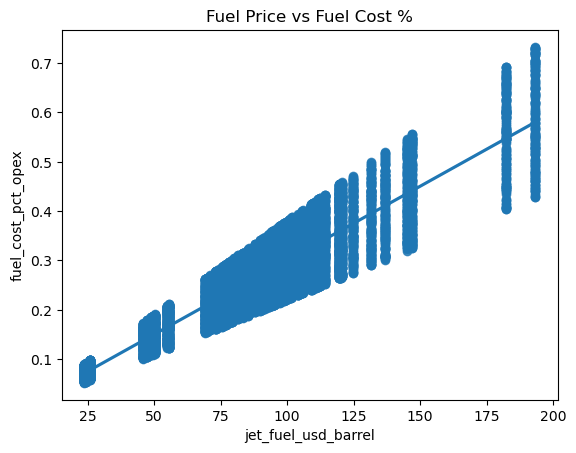

In [15]:
sns.regplot(x='jet_fuel_usd_barrel', y='fuel_cost_pct_opex', data=df)
plt.title("Fuel Price vs Fuel Cost %")
plt.show()

The plot shows a strong positive linear relationship between jet fuel price and fuel cost percentage. 
As fuel prices increase, the share of fuel in airline operating costs rises consistently. 
This indicates that fuel price is a major driver of airline expenses.

In [16]:
df.groupby('conflict_phase')['total_fare_usd'].mean().sort_values()

conflict_phase
COVID-19 Collapse         401.264929
Pre-Pandemic Baseline    1016.689468
Gaza-Israel Conflict     1133.829048
Stabilisation            1154.232054
Pre-Iran Escalation      1197.394020
Recovery & Surge         1293.678781
Ukraine War Shock        1560.867891
US-Iran War Conflict     2660.082864
Name: total_fare_usd, dtype: float64

Ticket prices vary significantly across different phases. 
Prices are lowest during COVID-19 collapse and highest during major conflict periods like US-Iran war. 
This indicates global events strongly impact airline pricing.

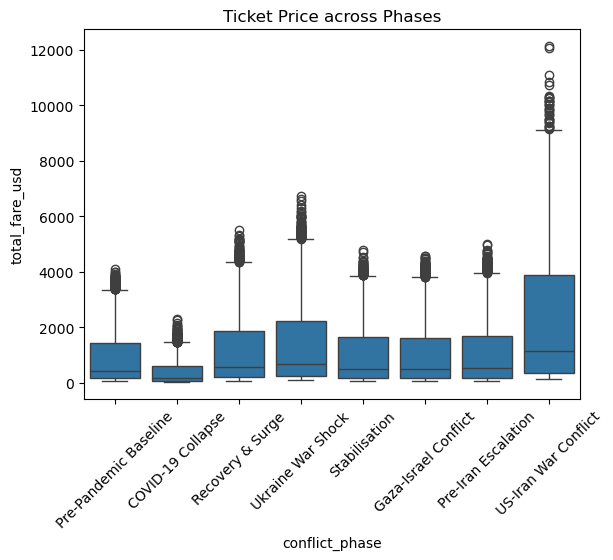

In [17]:
sns.boxplot(x='conflict_phase', y='total_fare_usd', data=df)
plt.xticks(rotation=45)
plt.title("Ticket Price across Phases")
plt.show()

The boxplot shows clear differences in ticket price distribution across phases. 
Conflict periods have higher median prices and greater variability, indicating increased uncertainty and pricing fluctuations.

The analysis shows that fuel prices have a strong impact on airline operating costs but only a limited direct impact on ticket prices. 

While regression and hypothesis testing confirm that fuel price is statistically significant, the low R² value indicates that ticket pricing is influenced by multiple factors beyond fuel cost. Airlines do not fully pass fuel cost increases to customers.

Additionally, external events like geopolitical conflicts and COVID-19 significantly affect ticket prices, causing major fluctuations across different phases.

Overall, fuel prices drive costs, but ticket prices are determined by a combination of demand, market conditions, and external events.